# **Imports**

In [1]:
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchsummary import summary

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, accuracy_score)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# **Config / Hyperparameters**

In [2]:
IMG_SIZE     = 150
BATCH_SIZE   = 128
NUM_EPOCHS   = 30        
LR           = 1.5e-3
WEIGHT_DECAY = 5e-4
NUM_CLASSES  = 6
VAL_SPLIT    = 0.15
MIXUP_ALPHA  = 0.2  

TRAIN_DIR = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR  = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"

# **Explore dataset**

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train counts: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}
Test counts : {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


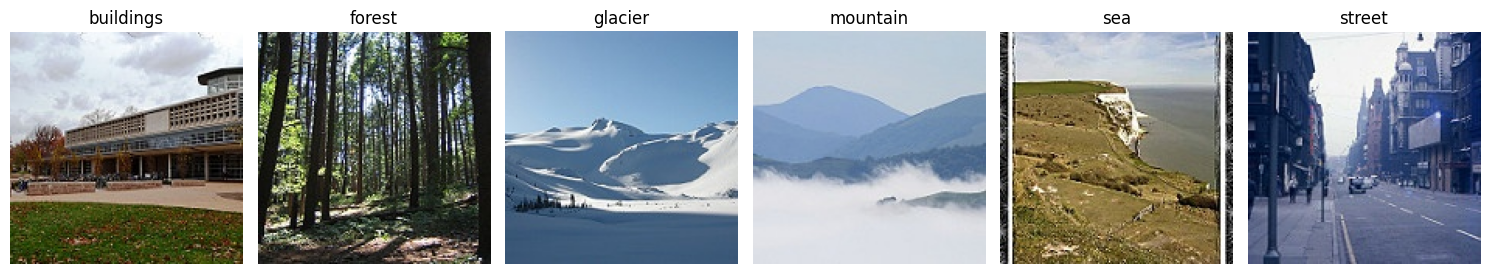

In [3]:
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes}
print("Train counts:", counts)
print("Test counts :",
      {c: len(os.listdir(os.path.join(TEST_DIR, c))) for c in classes})

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, c in zip(axes, classes):
    img_name = os.listdir(os.path.join(TRAIN_DIR, c))[0]
    img = Image.open(os.path.join(TRAIN_DIR, c, img_name))
    ax.imshow(img); ax.set_title(c); ax.axis('off')
plt.tight_layout(); plt.show()

# **Transforms + DataLoaders**

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

val_size   = int(len(full_train) * VAL_SPLIT)
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
val_ds.dataset.transform = eval_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = full_train.classes
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Classes:", class_names)

Train: 11929 | Val: 2105 | Test: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# **Define custom CNN**

In [5]:
class CustomCNN(nn.Module):
    """
    Custom CNN: 4 conv blocks (Conv-BN-ReLU-Conv-BN-ReLU-Pool)
    Progressive channel doubling: 32 -> 64 -> 128 -> 256
    BatchNorm + Dropout for regularization.
    """
    def __init__(self, num_classes=6):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.block1 = block(3,   32)
        self.block2 = block(32,  64)
        self.block3 = block(64,  128)
        self.block4 = block(128, 256)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.classifier(x)

model = CustomCNN(NUM_CLASSES).to(device)

# **Model summary**

In [6]:
summary(model, (3, IMG_SIZE, IMG_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 150, 150]             896
       BatchNorm2d-2         [-1, 32, 150, 150]              64
              ReLU-3         [-1, 32, 150, 150]               0
            Conv2d-4         [-1, 32, 150, 150]           9,248
       BatchNorm2d-5         [-1, 32, 150, 150]              64
              ReLU-6         [-1, 32, 150, 150]               0
         MaxPool2d-7           [-1, 32, 75, 75]               0
            Conv2d-8           [-1, 64, 75, 75]          18,496
       BatchNorm2d-9           [-1, 64, 75, 75]             128
             ReLU-10           [-1, 64, 75, 75]               0
           Conv2d-11           [-1, 64, 75, 75]          36,928
      BatchNorm2d-12           [-1, 64, 75, 75]             128
             ReLU-13           [-1, 64, 75, 75]               0
        MaxPool2d-14           [-1, 64,

# **Loss, optimizer, scheduler**

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# T_0=15 -> restarts at epoch 15, completing exactly 2 cycles across 30 epochs
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=1, eta_min=1e-6)

# **Training**

In [8]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
                x_mix, y_a, y_b, lam = mixup_data(x, y, MIXUP_ALPHA)
                out = model(x_mix)
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                loss.backward()
                optimizer.step()
                correct += (lam * (out.argmax(1) == y_a).float() +
                            (1 - lam) * (out.argmax(1) == y_b).float()).sum().item()
            else:
                out = model(x)
                loss = criterion(out, y)
                correct += (out.argmax(1) == y).sum().item()
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    return total_loss / total, correct / total

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    curr_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f} acc={vl_acc:.4f} | "
          f"lr={curr_lr:.6f} | time={time.time()-t0:.1f}s")

# Loads whichever epoch had the best val acc across the full 30-epoch run
model.load_state_dict(best_weights)
print(f"\nBest val acc: {best_val_acc:.4f}")

Epoch 01/30 | train_loss=1.2680 acc=0.5724 | val_loss=1.1147 acc=0.6347 | lr=0.001484 | time=42.8s
Epoch 02/30 | train_loss=1.1303 acc=0.6843 | val_loss=1.1980 acc=0.5910 | lr=0.001435 | time=35.9s
Epoch 03/30 | train_loss=1.0328 acc=0.7362 | val_loss=0.8796 acc=0.7696 | lr=0.001357 | time=38.8s
Epoch 04/30 | train_loss=1.0260 acc=0.7437 | val_loss=0.8209 acc=0.8029 | lr=0.001252 | time=36.9s
Epoch 05/30 | train_loss=0.9888 acc=0.7593 | val_loss=0.7393 acc=0.8618 | lr=0.001125 | time=36.9s
Epoch 06/30 | train_loss=0.9662 acc=0.7722 | val_loss=0.8671 acc=0.7967 | lr=0.000982 | time=37.2s
Epoch 07/30 | train_loss=0.9611 acc=0.7785 | val_loss=0.7751 acc=0.8428 | lr=0.000829 | time=36.8s
Epoch 08/30 | train_loss=0.9766 acc=0.7687 | val_loss=0.7563 acc=0.8527 | lr=0.000672 | time=36.9s
Epoch 09/30 | train_loss=0.9059 acc=0.8007 | val_loss=0.7586 acc=0.8409 | lr=0.000519 | time=37.4s
Epoch 10/30 | train_loss=0.9427 acc=0.7851 | val_loss=0.7526 acc=0.8523 | lr=0.000376 | time=37.0s
Epoch 11/3

# **Plot curves**

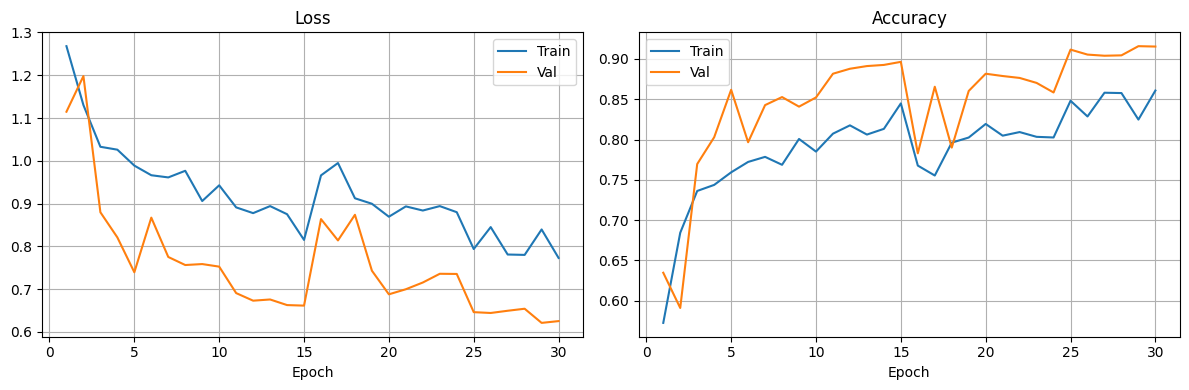

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax[0].plot(epochs_range, history["train_loss"], label="Train")
ax[0].plot(epochs_range, history["val_loss"],   label="Val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(epochs_range, history["train_acc"], label="Train")
ax[1].plot(epochs_range, history["val_acc"],   label="Val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.show()

# **Evaluate on test set**

In [14]:
def predict_with_tta(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out1 = torch.softmax(model(x), dim=1)
            out2 = torch.softmax(model(torch.flip(x, dims=[3])), dim=1)  # horizontal flip
            avg_out = (out1 + out2) / 2
            preds = avg_out.argmax(1).cpu().numpy()
            all_preds.extend(preds); all_labels.extend(y.numpy())
    return all_preds, all_labels

all_preds, all_labels = predict_with_tta(model, test_loader)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy (with TTA): {test_acc:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Test Accuracy (with TTA): 0.9107

Classification Report:
              precision    recall  f1-score   support

   buildings     0.9180    0.8970    0.9074       437
      forest     0.9831    0.9810    0.9820       474
     glacier     0.8953    0.8354    0.8644       553
    mountain     0.8366    0.8876    0.8614       525
         sea     0.9273    0.9510    0.9390       510
      street     0.9167    0.9222    0.9194       501

    accuracy                         0.9107      3000
   macro avg     0.9129    0.9124    0.9123      3000
weighted avg     0.9112    0.9107    0.9106      3000



# **Confusion matrix**

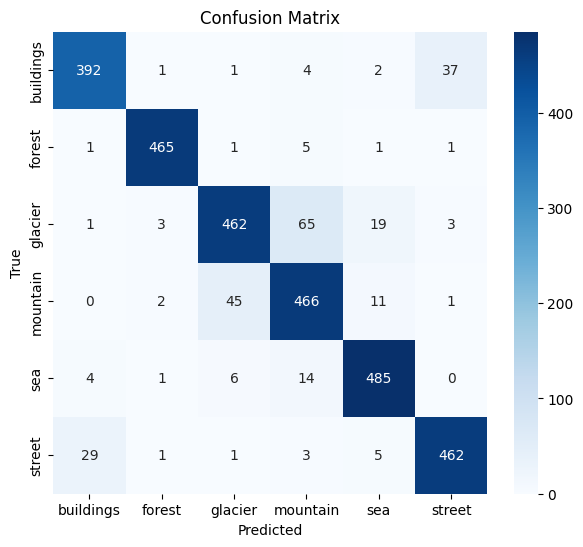

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

# **Per-class analysis**

In [16]:
prec, rec, f1, sup = precision_recall_fscore_support(all_labels, all_preds)
df = pd.DataFrame({
    "Class": class_names,
    "Precision": prec.round(4),
    "Recall": rec.round(4),
    "F1": f1.round(4),
    "Support": sup
})
print(df.to_string(index=False))

best_idx  = int(np.argmax(f1))
worst_idx = int(np.argmin(f1))
print(f"\nBest  class : {class_names[best_idx]}  (F1={f1[best_idx]:.4f})")
print(f"Worst class : {class_names[worst_idx]} (F1={f1[worst_idx]:.4f})")

    Class  Precision  Recall     F1  Support
buildings     0.9180  0.8970 0.9074      437
   forest     0.9831  0.9810 0.9820      474
  glacier     0.8953  0.8354 0.8644      553
 mountain     0.8366  0.8876 0.8614      525
      sea     0.9273  0.9510 0.9390      510
   street     0.9167  0.9222 0.9194      501

Best  class : forest  (F1=0.9820)
Worst class : mountain (F1=0.8614)


# **Save model weights**

In [17]:
SAVE_PATH = "/kaggle/working/CNN_22_47989_2.pth"   # rename to your actual student ID
torch.save(model.state_dict(), SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
print(f"Saved model: {SAVE_PATH} | Size: {size_mb:.2f} MB")

Saved model: /kaggle/working/CNN_22_47989_2.pth | Size: 4.63 MB
